In [1]:
import pandas as pd

df = pd.read_csv('../../../01_data_pipeline/datasets/enriched/system_events_enriched.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp'])
df.head()

,host,process_name,pid,message,timestamp,hour,day_of_week,is_weekend,off_hours,is_system_process,rare_process,first_seen_time,first_seen,session_id,first_seen_session,count_last_hour
0,Peters-Air,syslogd,388,ASL Sender Statistics,2026-01-23 00:14:01+00:00,0,4,False,1,1,0,2026-01-23 00:14:01+00:00,1,0,1,1.0
1,Peters-Air,syslogd,388,ASL Sender Statistics,2026-01-23 00:30:21+00:00,0,4,False,1,1,0,2026-01-23 00:14:01+00:00,0,0,0,2.0
2,Peters-Air,syslogd,388,"Configuration Notice: ASL Module ""com.apple.Me...",2026-01-23 00:30:22+00:00,0,4,False,1,1,0,2026-01-23 00:14:01+00:00,0,0,0,3.0
3,Peters-Air,syslogd,388,"Configuration Notice: ASL Module ""com.apple.mk...",2026-01-23 00:30:22+00:00,0,4,False,1,1,0,2026-01-23 00:14:01+00:00,0,0,0,4.0
4,Peters-Air,syslogd,388,"Configuration Notice: ASL Module ""com.apple.co...",2026-01-23 00:30:22+00:00,0,4,False,1,1,0,2026-01-23 00:14:01+00:00,0,0,0,5.0


In [2]:
df[['off_hours','rare_process', 'first_seen', 'count_last_hour']].describe()

,off_hours,rare_process,first_seen,count_last_hour
count,58.000000,58.0,58.000000,58.000000
mean,0.586207,0.0,0.017241,5.913793
std,0.496814,0.0,0.131306,3.752354
min,0.000000,0.0,0.000000,1.000000
25%,0.000000,0.0,0.000000,4.000000
50%,1.000000,0.0,0.000000,4.000000
75%,1.000000,0.0,0.000000,5.000000
max,1.000000,0.0,1.000000,17.000000


In [3]:
import matplotlib.pyplot as plt
import numpy as np

df=df.dropna(subset=['timestamp'])

df.shape

(58, 16)

In [4]:
process_counts = df['process_name'].value_counts()
process_counts.head(10)

process_name
syslogd    58
Name: count, dtype: int64

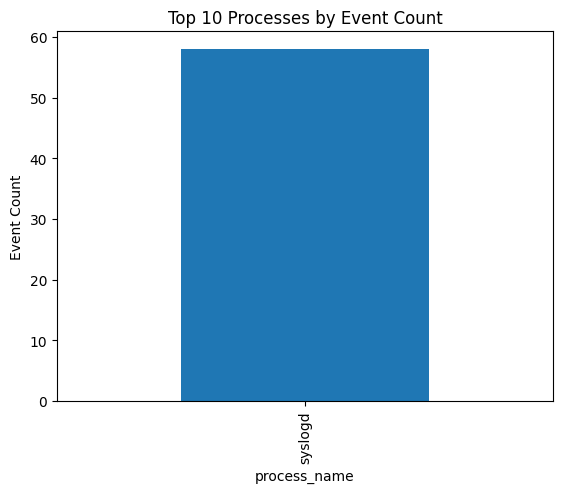

In [5]:
process_counts.head(10).plot(kind='bar')
plt.title("Top 10 Processes by Event Count")
plt.ylabel("Event Count")
plt.show()

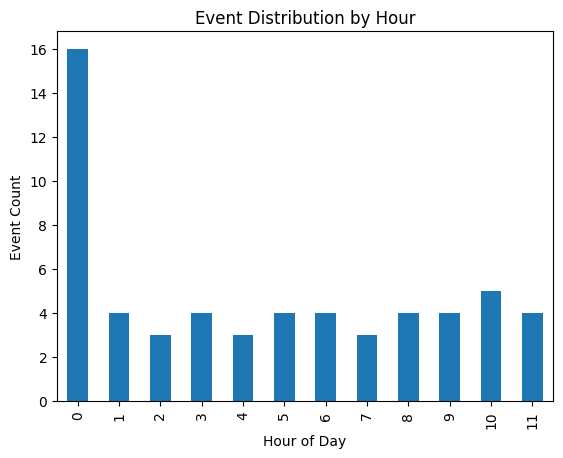

In [6]:
hour_counts = df['hour'].value_counts().sort_index()

hour_counts.plot(kind='bar')
plt.title("Event Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Event Count")
plt.show()

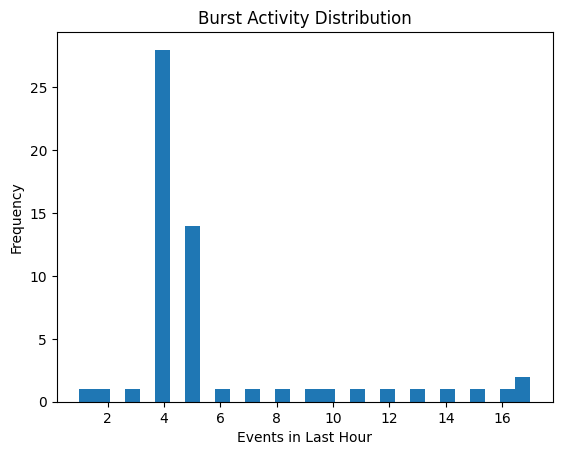

In [7]:
plt.hist(df['count_last_hour'], bins=30)
plt.title("Burst Activity Distribution")
plt.xlabel("Events in Last Hour")
plt.ylabel("Frequency")
plt.show()

In [8]:
from scipy.stats import zscore

df['burst_zscore'] = zscore(df['count_last_hour'])

df[df['burst_zscore'] > 2][
    ['timestamp','process_name','count_last_hour','burst_zscore']
].head(10)

,timestamp,process_name,count_last_hour,burst_zscore
13,2026-01-23 00:30:22+00:00,syslogd,14.0,2.173790
14,2026-01-23 00:30:22+00:00,syslogd,15.0,2.442617
15,2026-01-23 00:46:31+00:00,syslogd,16.0,2.711444
16,2026-01-23 01:03:06+00:00,syslogd,17.0,2.980271
17,2026-01-23 01:19:15+00:00,syslogd,17.0,2.980271


In [9]:
df['suspicious_proxy'] = (
    (df['off_hours'] == 1) |
    (df['rare_process'] == 1) |
    (df['burst_zscore'] > 2)
).astype(int)

In [10]:
P_suspicious = df['suspicious_proxy'].mean()
P_normal = 1 - P_suspicious

P_suspicious, P_normal

(np.float64(0.5862068965517241), np.float64(0.4137931034482759))

In [11]:
P_off_given_susp = df[df['suspicious_proxy'] == 1]['off_hours'].mean()
P_rare_given_susp = df[df['suspicious_proxy'] == 1]['rare_process'].mean()
P_first_given_susp = df[df['suspicious_proxy'] == 1]['first_seen'].mean()

P_off_given_susp, P_rare_given_susp, P_first_given_susp

(np.float64(1.0), np.float64(0.0), np.float64(0.029411764705882353))

In [12]:
P_off_given_normal = df[df['suspicious_proxy'] == 0]['off_hours'].mean()
P_rare_given_normal = df[df['suspicious_proxy'] == 0]['rare_process'].mean()
P_first_given_normal = df[df['suspicious_proxy'] == 0]['first_seen'].mean()

P_off_given_normal, P_rare_given_normal, P_first_given_normal

(np.float64(0.0), np.float64(0.0), np.float64(0.0))

In [13]:
def bayes_score(row):
    likelihood_s = (
        P_suspicious *
        (P_off_given_susp if row['off_hours'] else 1 - P_off_given_susp) *
        (P_rare_given_susp if row['rare_process'] else 1 - P_rare_given_susp) *
        (P_first_given_susp if row['first_seen'] else 1 - P_first_given_susp)
    )
    
    likelihood_n = (
        P_normal *
        (P_off_given_normal if row['off_hours'] else 1 - P_off_given_normal) *
        (P_rare_given_normal if row['rare_process'] else 1 - P_rare_given_normal) *
        (P_first_given_normal if row['first_seen'] else 1 - P_first_given_normal)
    )
    
    return likelihood_s / (likelihood_s + likelihood_n)

df['bayes_risk_score'] = df.apply(bayes_score, axis=1)

In [14]:
df.sort_values('bayes_risk_score', ascending=False)[
    ['timestamp','process_name','message', 'bayes_risk_score','off_hours','rare_process','first_seen']
].head(10)

,timestamp,process_name,message,bayes_risk_score,off_hours,rare_process,first_seen
0,2026-01-23 00:14:01+00:00,syslogd,ASL Sender Statistics,1.0,1,0,1
26,2026-01-23 03:57:09+00:00,syslogd,ASL Sender Statistics,1.0,1,0,0
20,2026-01-23 02:11:30+00:00,syslogd,ASL Sender Statistics,1.0,1,0,0
21,2026-01-23 02:29:41+00:00,syslogd,ASL Sender Statistics,1.0,1,0,0
22,2026-01-23 02:48:29+00:00,syslogd,ASL Sender Statistics,1.0,1,0,0
23,2026-01-23 03:06:15+00:00,syslogd,ASL Sender Statistics,1.0,1,0,0
24,2026-01-23 03:22:16+00:00,syslogd,ASL Sender Statistics,1.0,1,0,0
25,2026-01-23 03:38:56+00:00,syslogd,ASL Sender Statistics,1.0,1,0,0
27,2026-01-23 04:13:10+00:00,syslogd,ASL Sender Statistics,1.0,1,0,0
18,2026-01-23 01:36:35+00:00,syslogd,ASL Sender Statistics,1.0,1,0,0


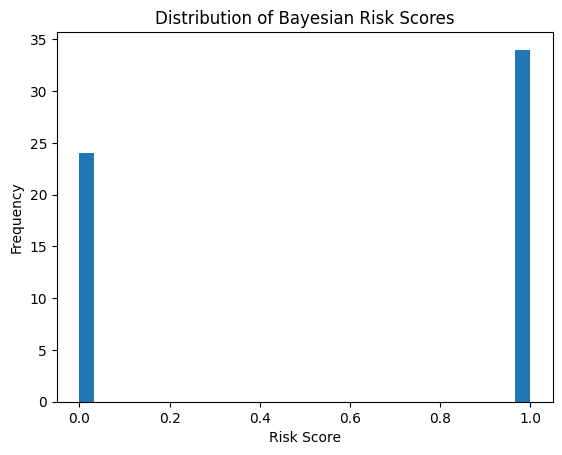

In [15]:
import matplotlib.pyplot as plt

plt.hist(df['bayes_risk_score'], bins=30)
plt.title("Distribution of Bayesian Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

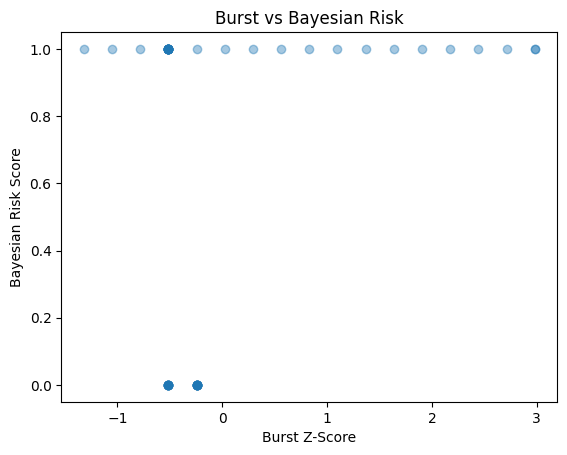

In [16]:
plt.scatter(df['burst_zscore'], df['bayes_risk_score'], alpha=0.4)
plt.xlabel("Burst Z-Score")
plt.ylabel("Bayesian Risk Score")
plt.title("Burst vs Bayesian Risk")
plt.show()

In [17]:
threshold = df['bayes_risk_score'].quantile(0.99)

high_risk = df[df['bayes_risk_score'] >= threshold]

high_risk[['timestamp','message','bayes_risk_score','off_hours','burst_zscore']].head(20)

,timestamp,message,bayes_risk_score,off_hours,burst_zscore
0,2026-01-23 00:14:01+00:00,ASL Sender Statistics,1.0,1,-1.320960
1,2026-01-23 00:30:21+00:00,ASL Sender Statistics,1.0,1,-1.052133
2,2026-01-23 00:30:22+00:00,"Configuration Notice: ASL Module ""com.apple.Me...",1.0,1,-0.783306
3,2026-01-23 00:30:22+00:00,"Configuration Notice: ASL Module ""com.apple.mk...",1.0,1,-0.514479
4,2026-01-23 00:30:22+00:00,"Configuration Notice: ASL Module ""com.apple.co...",1.0,1,-0.245652
5,2026-01-23 00:30:22+00:00,"Configuration Notice: ASL Module ""com.apple.io...",1.0,1,0.023175
6,2026-01-23 00:30:22+00:00,"Configuration Notice: ASL Module ""com.apple.pe...",1.0,1,0.292002
7,2026-01-23 00:30:22+00:00,"Configuration Notice: ASL Module ""com.apple.ma...",1.0,1,0.560829
8,2026-01-23 00:30:22+00:00,"Configuration Notice: ASL Module ""com.apple.mk...",1.0,1,0.829656
9,2026-01-23 00:30:22+00:00,"Configuration Notice: ASL Module ""com.apple.au...",1.0,1,1.098483
